# Linear Regression: Gradient Descent vs. Closed-Form OLS

### Mathematics for Machine Learning — Final Project
**Albert School × Mines Paris PSL**

**Dataset:** [Ames Housing](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) (Kaggle House Prices)

---

**Objectives:**
1. Implement linear regression with **gradient descent** from scratch
2. Tune learning rates and compare convergence behavior
3. Benchmark against the **closed-form OLS** solution (Normal Equation)
4. Freely explore the dataset using course concepts (PCA, regularization, hypothesis testing)

**Course connections:** Linear Algebra (S1) · Calculus & Optimization (S2) · Probability (S3) · Statistics (S4) · Advanced Optimization (S5)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('train.csv')
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 2} (excluding Id and SalePrice)")
print(f"Samples:  {df.shape[0]}")
print(f"\nTarget variable — SalePrice:")
print(f"  Mean:   ${df['SalePrice'].mean():,.0f}")
print(f"  Median: ${df['SalePrice'].median():,.0f}")
print(f"  Std:    ${df['SalePrice'].std():,.0f}")
print(f"  Range:  ${df['SalePrice'].min():,.0f} - ${df['SalePrice'].max():,.0f}")
df.head()

Dataset shape: (1460, 81)
Features: 79 (excluding Id and SalePrice)
Samples:  1460

Target variable — SalePrice:
  Mean:   $180,921
  Median: $163,000
  Std:    $79,443
  Range:  $34,900 - $755,000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Exploratory Data Analysis

We examine the target distribution, identify the most predictive features, and run a hypothesis test — connecting to **Sessions 3 & 4** (probability distributions, hypothesis testing).

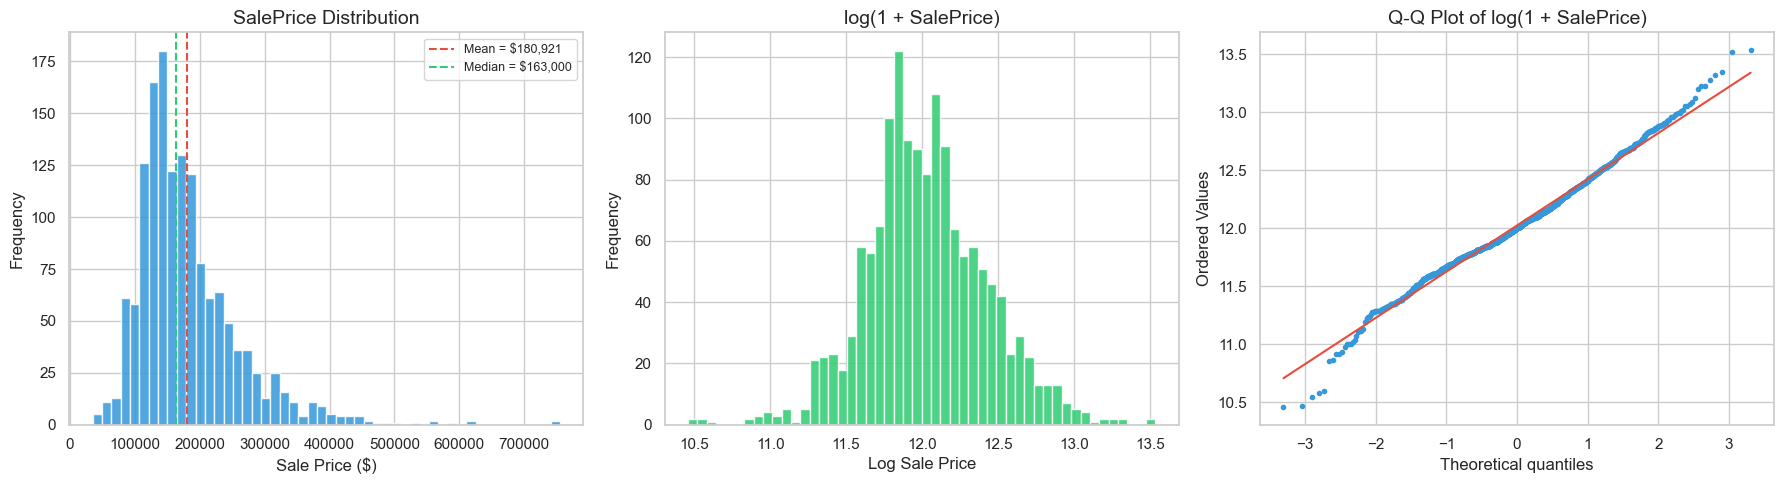

Raw skewness:  1.883  ->  Log skewness: 0.121
Shapiro-Wilk p-value (log): 0.0001
Log-transform reduces skewness from 1.88 to 0.12, approaching normality.


In [3]:
# --- SalePrice Distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['SalePrice'], bins=50, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['SalePrice'].mean(), color=COLORS[1], ls='--',
                label=f"Mean = ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color=COLORS[2], ls='--',
                label=f"Median = ${df['SalePrice'].median():,.0f}")
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].set_title('log(1 + SalePrice)')
axes[1].set_xlabel('Log Sale Price')
axes[1].set_ylabel('Frequency')

stats.probplot(log_price, plot=axes[2])
axes[2].set_title('Q-Q Plot of log(1 + SalePrice)')
axes[2].get_lines()[0].set(color=COLORS[0], markersize=3)
axes[2].get_lines()[1].set(color=COLORS[1])

plt.tight_layout()
plt.savefig('fig_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

skew_raw = df['SalePrice'].skew()
skew_log = log_price.skew()
_, p_shapiro = stats.shapiro(log_price.sample(500, random_state=42))
print(f"Raw skewness:  {skew_raw:.3f}  ->  Log skewness: {skew_log:.3f}")
print(f"Shapiro-Wilk p-value (log): {p_shapiro:.4f}")
print(f"Log-transform reduces skewness from {skew_raw:.2f} to {skew_log:.2f}, approaching normality.")

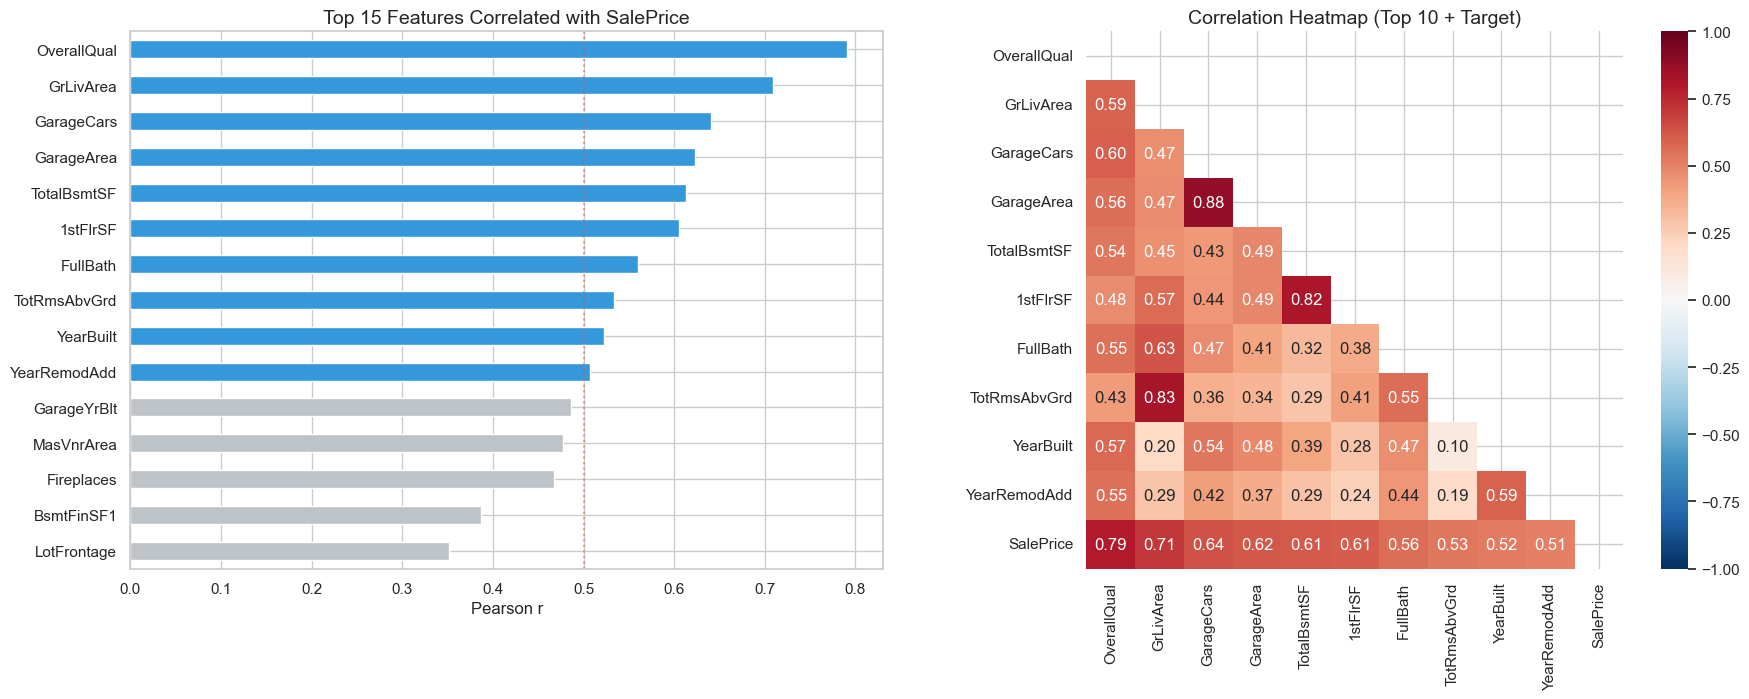

Top 10 features by correlation with SalePrice:
   1. OverallQual          r = 0.791
   2. GrLivArea            r = 0.709
   3. GarageCars           r = 0.640
   4. GarageArea           r = 0.623
   5. TotalBsmtSF          r = 0.614
   6. 1stFlrSF             r = 0.606
   7. FullBath             r = 0.561
   8. TotRmsAbvGrd         r = 0.534
   9. YearBuilt            r = 0.523
  10. YearRemodAdd         r = 0.507


In [4]:
# --- Correlation Analysis ---
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Id')
corr_price = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top15 = corr_price.head(15)
bar_colors = [COLORS[0] if i < 10 else '#bdc3c7' for i in range(len(top15))]
top15.plot(kind='barh', ax=axes[0], color=bar_colors)
axes[0].set_title('Top 15 Features Correlated with SalePrice')
axes[0].set_xlabel('Pearson r')
axes[0].axvline(x=0.5, color=COLORS[1], ls=':', alpha=0.5)
axes[0].invert_yaxis()

top10_feats = corr_price.head(10).index.tolist()
cm = df[top10_feats + ['SalePrice']].corr()
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, vmin=-1, vmax=1)
axes[1].set_title('Correlation Heatmap (Top 10 + Target)')

plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features by correlation with SalePrice:")
for i, (f, r) in enumerate(corr_price.head(10).items(), 1):
    print(f"  {i:2d}. {f:20s} r = {r:.3f}")

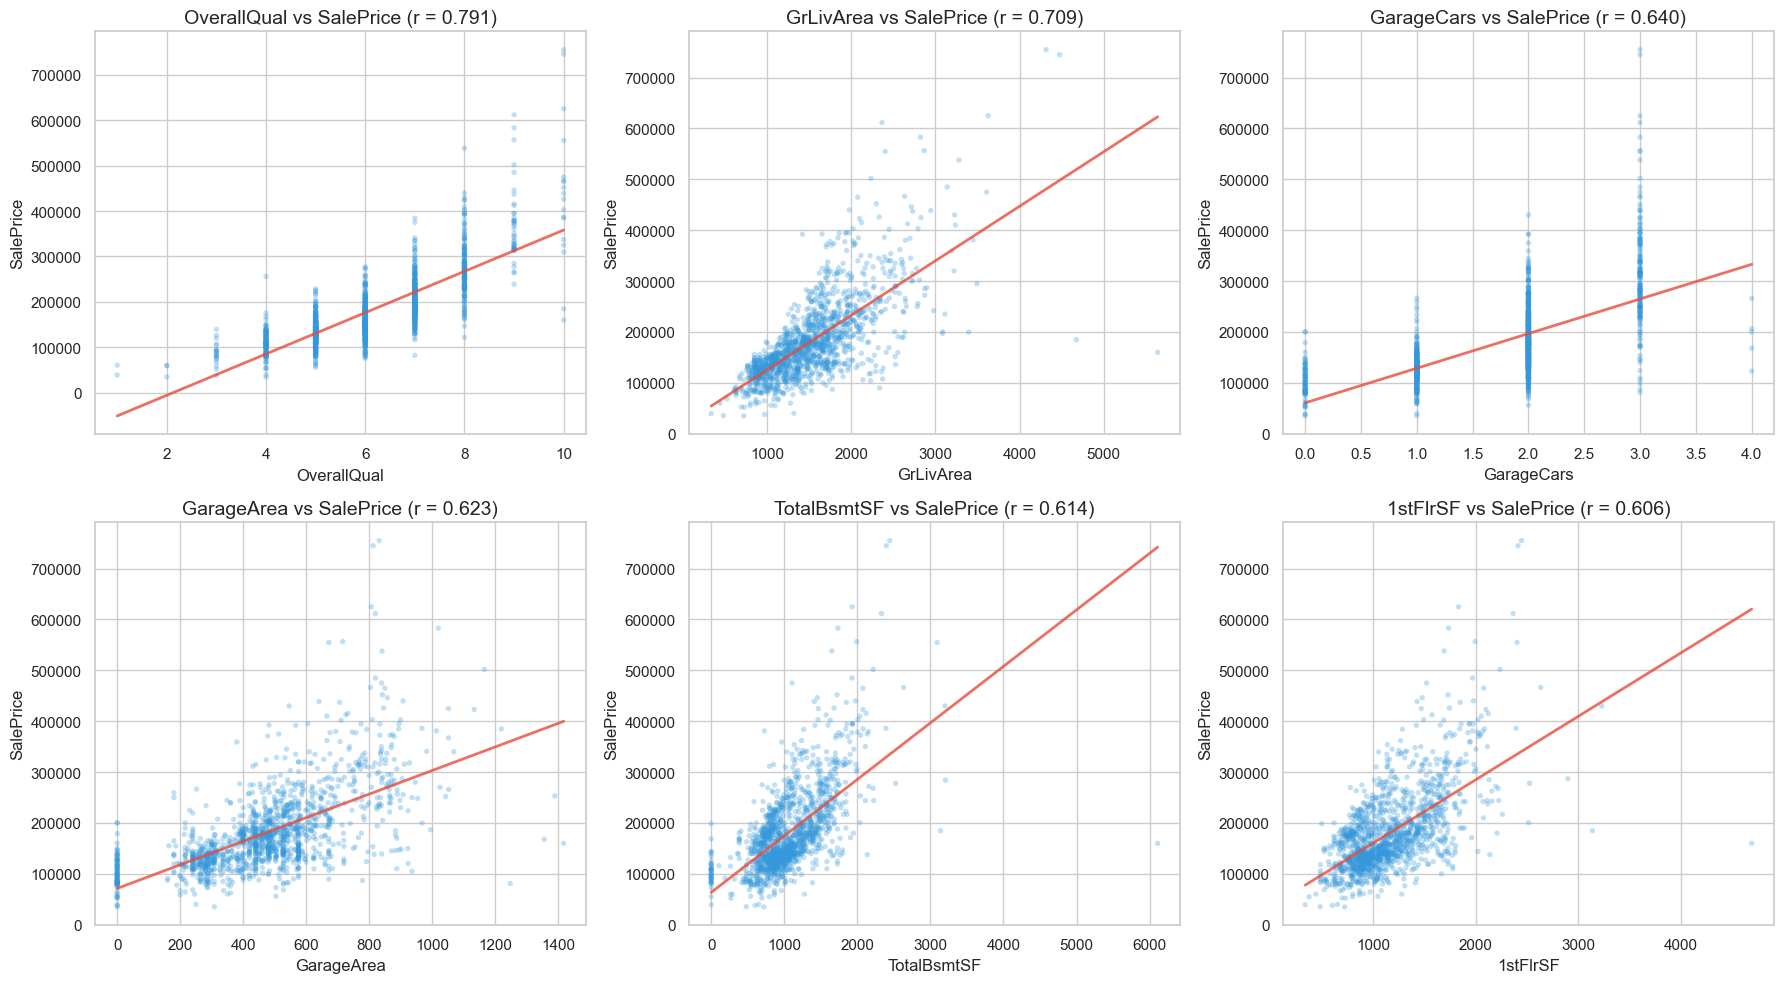

In [5]:
# --- Scatter Plots: Top 6 Features ---
top6 = corr_price.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(top6):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df['SalePrice'], alpha=0.3, s=15, color=COLORS[0], edgecolors='none')
    valid = df[feat].notna() & df['SalePrice'].notna()
    z = np.polyfit(df.loc[valid, feat], df.loc[valid, 'SalePrice'], 1)
    xl = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xl, np.polyval(z, xl), color=COLORS[1], lw=2, alpha=0.8)
    r = df[feat].corr(df['SalePrice'])
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice (r = {r:.3f})')
plt.tight_layout()
plt.savefig('fig_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Hypothesis Test (Session 4)

We test whether **Overall Quality** rating significantly affects house prices:

- $H_0$: $\mu_{\text{high}} = \mu_{\text{low}}$ (no price difference between quality groups)
- $H_1$: $\mu_{\text{high}} \neq \mu_{\text{low}}$ (significant difference)

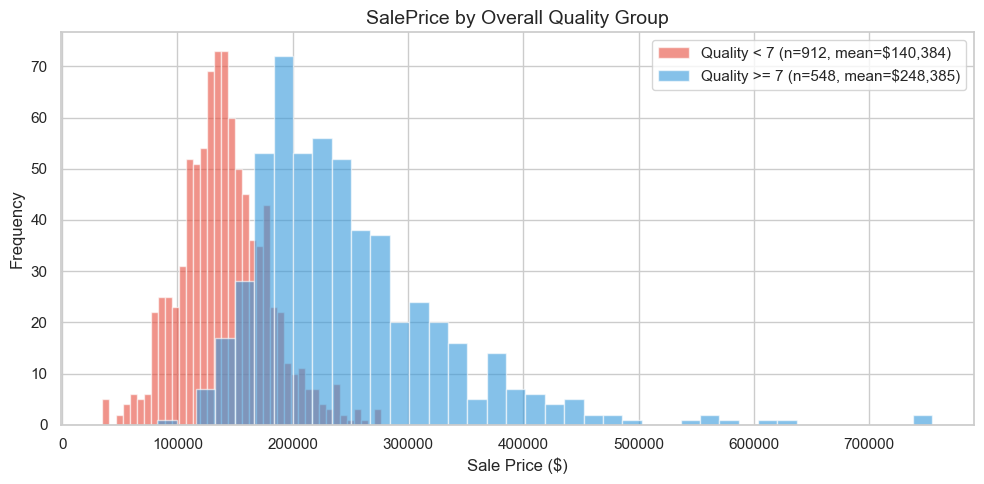

Welch's t-test: t = 28.214, p = 1.84e-116
Result: Reject H0 at alpha = 0.05
Overall quality has a statistically significant effect on sale price.


In [6]:
high_q = df[df['OverallQual'] >= 7]['SalePrice']
low_q  = df[df['OverallQual'] < 7]['SalePrice']
t_stat, p_val = stats.ttest_ind(high_q, low_q, equal_var=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(low_q,  bins=40, alpha=0.6, color=COLORS[1],
        label=f'Quality < 7 (n={len(low_q)}, mean=${low_q.mean():,.0f})')
ax.hist(high_q, bins=40, alpha=0.6, color=COLORS[0],
        label=f'Quality >= 7 (n={len(high_q)}, mean=${high_q.mean():,.0f})')
ax.set_xlabel('Sale Price ($)')
ax.set_ylabel('Frequency')
ax.set_title('SalePrice by Overall Quality Group')
ax.legend()
plt.tight_layout()
plt.savefig('fig_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Welch's t-test: t = {t_stat:.3f}, p = {p_val:.2e}")
print(f"Result: {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'} at alpha = 0.05")
print(f"Overall quality has a statistically significant effect on sale price.")

## 2. Data Preprocessing

### Why Standardization Matters for Gradient Descent

Feature standardization ($z = \frac{x - \mu}{\sigma}$) is **critical** for gradient descent. Without it, features with large scales dominate the gradient, causing slow zigzag convergence.

Standardization improves the **condition number** $\kappa(\mathbf{X}^T\mathbf{X}) = \lambda_{\max} / \lambda_{\min}$. A lower condition number means a more spherical cost surface, enabling faster convergence with a larger learning rate.

We also apply $\log(1 + y)$ to the target to reduce skewness (Session 3).

In [7]:
# Select top 10 features by correlation
selected = corr_price.head(10).index.tolist()
print(f"Selected features: {selected}")

X = df[selected].copy()
y = np.log1p(df['SalePrice'].values)

# Impute missing values with median
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing values (imputed with median):")
    print(missing[missing > 0].to_string())
X = X.fillna(X.median())

# Train/test split (80/20)
np.random.seed(42)
n = len(X)
idx = np.random.permutation(n)
split = int(0.8 * n)
train_i, test_i = idx[:split], idx[split:]

X_train_raw, X_test_raw = X.values[train_i], X.values[test_i]
y_train, y_test = y[train_i], y[test_i]

# Standardize (z-score normalization)
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
X_train = (X_train_raw - mu) / sigma
X_test  = (X_test_raw - mu) / sigma

print(f"\nTrain: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples, Features: {X_train.shape[1]}")

# Condition number analysis
XtX = X_train.T @ X_train / X_train.shape[0]
eigs = np.linalg.eigvalsh(XtX)
print(f"\nCondition number kappa(X^TX/n): {eigs[-1]/eigs[0]:.1f}")
print(f"lambda_max = {eigs[-1]:.3f},  lambda_min = {eigs[0]:.3f}")
print(f"Theoretical max learning rate: alpha < {2/eigs[-1]:.3f}")

Selected features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

Train: 1168 samples, Test: 292 samples, Features: 10

Condition number kappa(X^TX/n): 50.1
lambda_max = 5.270,  lambda_min = 0.105
Theoretical max learning rate: alpha < 0.380


## 3. Mathematical Foundations (Session 2)

### 3.1 Cost Function

We model house prices as a linear combination: $\hat{y}_i = \mathbf{x}_i^T \boldsymbol{\theta} + b$

The **Mean Squared Error** cost function:

$$J(\boldsymbol{\theta}, b) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 = \frac{1}{2n} \|\mathbf{X}\boldsymbol{\theta} + b\mathbf{1} - \mathbf{y}\|_2^2$$

### 3.2 Gradient

Applying the chain rule to each parameter:

$$\frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{1}{n} \mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} + b\mathbf{1} - \mathbf{y}), \qquad \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)$$

### 3.3 Gradient Descent Update Rule

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \alpha\,\nabla_{\boldsymbol{\theta}} J, \qquad b_{t+1} = b_t - \alpha\,\frac{\partial J}{\partial b}$$

For guaranteed convergence: $0 < \alpha < \frac{2}{\lambda_{\max}(\mathbf{X}^T\mathbf{X}/n)}$

### 3.4 Normal Equation (Closed-Form OLS)

Setting $\nabla J = 0$ with augmented matrix $\tilde{\mathbf{X}} = [\mathbf{1} \mid \mathbf{X}]$:

$$\boxed{\boldsymbol{\theta}^* = (\tilde{\mathbf{X}}^T\tilde{\mathbf{X}})^{-1}\tilde{\mathbf{X}}^T\mathbf{y}}$$

Exact solution in $O(np^2 + p^3)$ — no iteration, no hyperparameters.

## 4. Closed-Form OLS (Normal Equation)

We first solve analytically. This is our **ground-truth benchmark** — gradient descent should converge to the same solution.

In [8]:
class OLSRegression:
    def fit(self, X, y):
        X_b = np.c_[np.ones(X.shape[0]), X]
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        self.bias = self.theta[0]
        self.weights = self.theta[1:]
        return self

    def predict(self, X):
        return np.c_[np.ones(X.shape[0]), X] @ self.theta

def evaluate(model, Xtr, ytr, Xte, yte):
    yp_tr, yp_te = model.predict(Xtr), model.predict(Xte)
    return {
        'rmse_tr': np.sqrt(np.mean((yp_tr - ytr)**2)),
        'rmse_te': np.sqrt(np.mean((yp_te - yte)**2)),
        'r2_tr': 1 - np.sum((yp_tr - ytr)**2) / np.sum((ytr - ytr.mean())**2),
        'r2_te': 1 - np.sum((yp_te - yte)**2) / np.sum((yte - yte.mean())**2),
    }

t0 = time.time()
ols = OLSRegression().fit(X_train, y_train)
ols_time = time.time() - t0
ols_m = evaluate(ols, X_train, y_train, X_test, y_test)

print("Closed-Form OLS Results")
print("=" * 40)
print(f"Train RMSE: {ols_m['rmse_tr']:.4f}")
print(f"Test RMSE:  {ols_m['rmse_te']:.4f}")
print(f"Train R2:   {ols_m['r2_tr']:.4f}")
print(f"Test R2:    {ols_m['r2_te']:.4f}")
print(f"Time:       {ols_time*1000:.2f} ms")

Closed-Form OLS Results
Train RMSE: 0.1758
Test RMSE:  0.1413
Train R2:   0.8132
Test R2:    0.8528
Time:       0.30 ms


## 5. Gradient Descent from Scratch

We implement batch gradient descent and verify convergence to the OLS solution.

In [9]:
class GradientDescentLR:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n, p = X.shape
        self.weights = np.zeros(p)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.n_iter):
            y_hat = X @ self.weights + self.bias
            r = y_hat - y

            dw = (1/n) * (X.T @ r)
            db = (1/n) * np.sum(r)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.cost_history.append((1/(2*n)) * np.sum(r**2))
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

print("GradientDescentLR class defined.")

GradientDescentLR class defined.


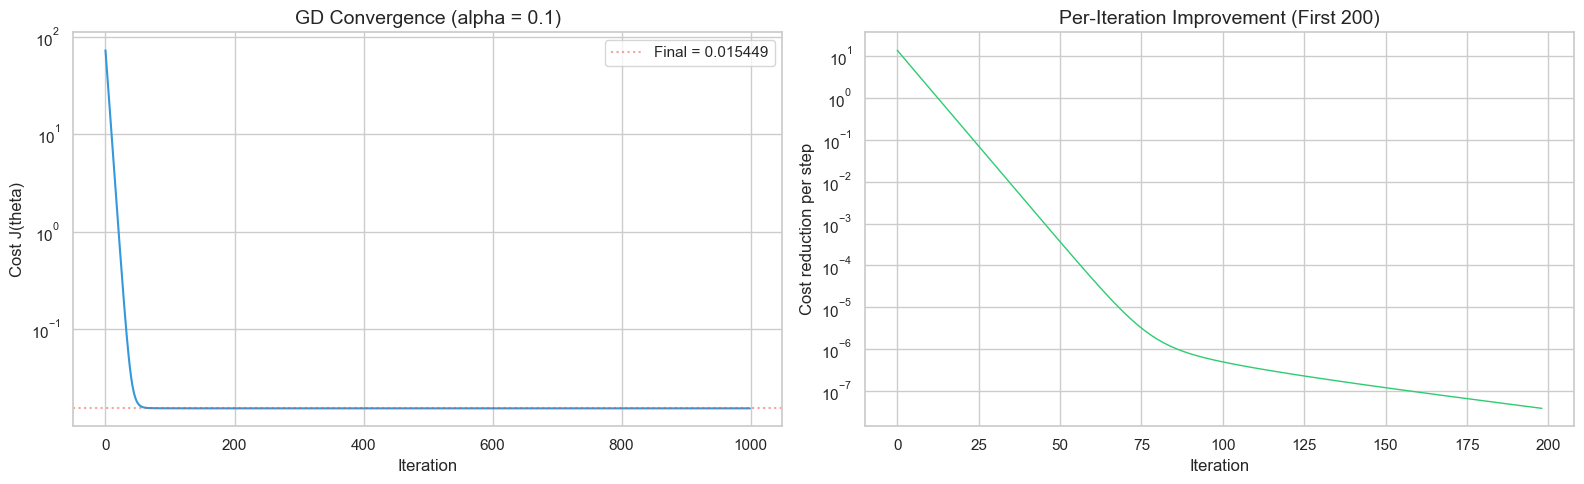

GD Results (alpha=0.1, T=1000)
Train RMSE: 0.1758
Test RMSE:  0.1413
Train R2:   0.8132
Test R2:    0.8528
Time:       23.44 ms

Max |theta_GD - theta_OLS|: 0.000001


In [10]:
# Train with alpha = 0.1
t0 = time.time()
gd = GradientDescentLR(lr=0.1, n_iter=1000).fit(X_train, y_train)
gd_time = time.time() - t0
gd_m = evaluate(gd, X_train, y_train, X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(gd.cost_history, color=COLORS[0], lw=1.5)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(theta)')
axes[0].set_title('GD Convergence (alpha = 0.1)')
axes[0].set_yscale('log')
axes[0].axhline(gd.cost_history[-1], color=COLORS[1], ls=':', alpha=0.5,
                label=f'Final = {gd.cost_history[-1]:.6f}')
axes[0].legend()

costs = np.array(gd.cost_history[:200])
axes[1].plot(costs[:-1] - costs[1:], color=COLORS[2], lw=1)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost reduction per step')
axes[1].set_title('Per-Iteration Improvement (First 200)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('fig_gd_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"GD Results (alpha=0.1, T=1000)")
print("=" * 40)
print(f"Train RMSE: {gd_m['rmse_tr']:.4f}")
print(f"Test RMSE:  {gd_m['rmse_te']:.4f}")
print(f"Train R2:   {gd_m['r2_tr']:.4f}")
print(f"Test R2:    {gd_m['r2_te']:.4f}")
print(f"Time:       {gd_time*1000:.2f} ms")
print(f"\nMax |theta_GD - theta_OLS|: {np.max(np.abs(gd.weights - ols.weights)):.6f}")

## 6. Learning Rate Tuning

| $\alpha$ too small | $\alpha$ just right | $\alpha$ too large |
|:---|:---|:---|
| Slow convergence | Fast, stable | Oscillation / divergence |
| Many iterations wasted | Efficient training | Cost may increase |

**Theoretical bound:** $\alpha < 2 / \lambda_{\max}(\mathbf{X}^T\mathbf{X}/n)$

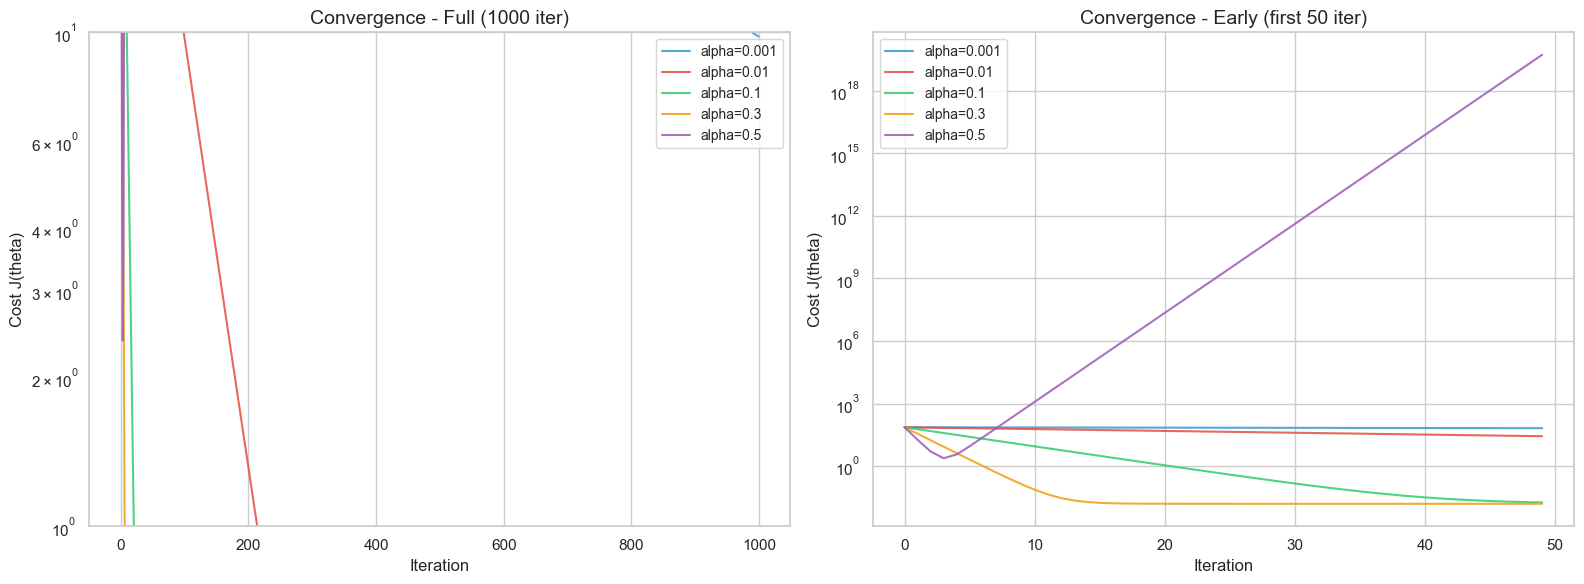

   alpha   Final Cost   Train RMSE    Test RMSE    Test R2
----------------------------------------------------------
   0.001     9.806424       4.4242       4.4324  -143.8265
   0.010     0.015468       0.1759       0.1424     0.8504
   0.100     0.015449       0.1758       0.1413     0.8528
   0.300     0.015449       0.1758       0.1413     0.8528
   0.500          inf          inf          inf       -inf


In [11]:
lrs = [0.001, 0.01, 0.1, 0.3, 0.5]
lr_models = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for lr, c in zip(lrs, COLORS):
    m = GradientDescentLR(lr=lr, n_iter=1000).fit(X_train, y_train)
    lr_models[lr] = m
    axes[0].plot(m.cost_history, label=f'alpha={lr}', color=c, lw=1.5, alpha=0.85)
    axes[1].plot(m.cost_history[:50], label=f'alpha={lr}', color=c, lw=1.5, alpha=0.85)

for ax, title in zip(axes, ['Full (1000 iter)', 'Early (first 50 iter)']):
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost J(theta)')
    ax.set_title(f'Convergence - {title}')
    ax.legend(fontsize=10)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'alpha':>8} {'Final Cost':>12} {'Train RMSE':>12} {'Test RMSE':>12} {'Test R2':>10}")
print("-" * 58)
for lr in lrs:
    m = lr_models[lr]
    me = evaluate(m, X_train, y_train, X_test, y_test)
    print(f"{lr:>8.3f} {m.cost_history[-1]:>12.6f} {me['rmse_tr']:>12.4f} {me['rmse_te']:>12.4f} {me['r2_te']:>10.4f}")

## 7. Gradient Descent vs. OLS — Full Comparison

| Aspect | Normal Equation (OLS) | Gradient Descent |
|:---|:---|:---|
| **Computation** | $O(np^2 + p^3)$, one-shot | $O(Tnp)$, iterative |
| **Hyperparameters** | None | $\alpha$, $T$ |
| **Scalability** | Poor for large $p$ | Scales to large $n$, $p$ |
| **Solution** | Exact | Approximate (converges to exact) |
| **Regularization** | Requires reformulation | Natural extension |

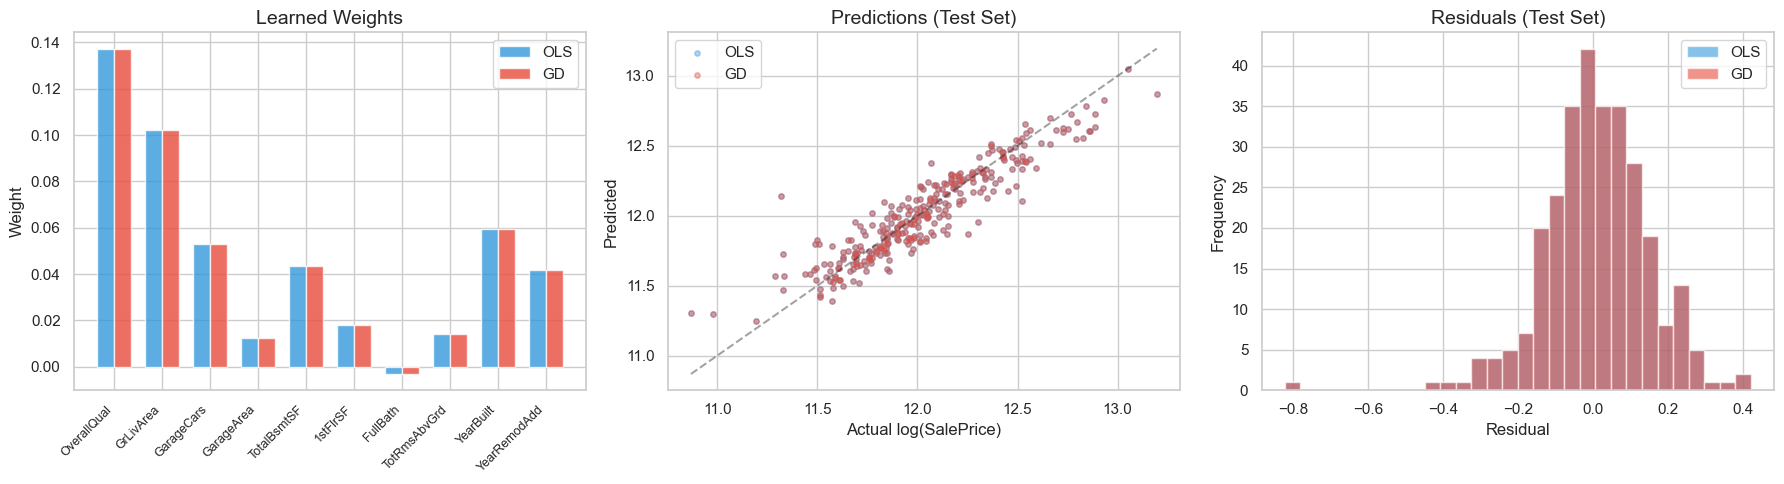


Metric                              OLS    GD (a=0.1)
Train RMSE                       0.1758        0.1758
Test RMSE                        0.1413        0.1413
Train R2                         0.8132        0.8132
Test R2                          0.8528        0.8528
Time (ms)                          0.30         23.44
Max |delta_theta|              0.000001           ---


In [12]:
best_gd = lr_models[0.1]
best_m = evaluate(best_gd, X_train, y_train, X_test, y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Weight comparison
x_pos = np.arange(len(selected))
w = 0.35
axes[0].bar(x_pos - w/2, ols.weights, w, label='OLS', color=COLORS[0], alpha=0.8)
axes[0].bar(x_pos + w/2, best_gd.weights, w, label='GD', color=COLORS[1], alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(selected, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Weight')
axes[0].set_title('Learned Weights')
axes[0].legend()

# Predictions vs actual
yp_ols = ols.predict(X_test)
yp_gd = best_gd.predict(X_test)
axes[1].scatter(y_test, yp_ols, alpha=0.4, s=15, color=COLORS[0], label='OLS')
axes[1].scatter(y_test, yp_gd, alpha=0.4, s=15, color=COLORS[1], label='GD')
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, 'k--', alpha=0.4)
axes[1].set_xlabel('Actual log(SalePrice)')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Predictions (Test Set)')
axes[1].legend()

# Residuals
axes[2].hist(y_test - yp_ols, bins=30, alpha=0.6, color=COLORS[0], label='OLS', edgecolor='white')
axes[2].hist(y_test - yp_gd, bins=30, alpha=0.6, color=COLORS[1], label='GD', edgecolor='white')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residuals (Test Set)')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("=" * 55)
print(f"{'Metric':<25} {'OLS':>13} {'GD (a=0.1)':>13}")
print("=" * 55)
print(f"{'Train RMSE':<25} {ols_m['rmse_tr']:>13.4f} {best_m['rmse_tr']:>13.4f}")
print(f"{'Test RMSE':<25} {ols_m['rmse_te']:>13.4f} {best_m['rmse_te']:>13.4f}")
print(f"{'Train R2':<25} {ols_m['r2_tr']:>13.4f} {best_m['r2_tr']:>13.4f}")
print(f"{'Test R2':<25} {ols_m['r2_te']:>13.4f} {best_m['r2_te']:>13.4f}")
print(f"{'Time (ms)':<25} {ols_time*1000:>13.2f} {gd_time*1000:>13.2f}")
print(f"{'Max |delta_theta|':<25} {np.max(np.abs(best_gd.weights - ols.weights)):>13.6f} {'---':>13}")
print("=" * 55)

## 8. Free Exploration

We apply two additional course concepts:

1. **PCA — Dimensionality Reduction** (Session 1): Eigendecomposition, explained variance, regression on principal components
2. **Ridge Regularization** (Session 5): $L_2$ penalty in gradient descent to control overfitting

### 8.1 Principal Component Analysis (Session 1)

PCA finds orthogonal directions of maximum variance via eigendecomposition:

$$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^T\mathbf{X}, \quad \mathbf{C}\mathbf{v}_k = \lambda_k \mathbf{v}_k$$

The eigenvectors $\mathbf{v}_k$ are **principal components**; eigenvalues $\lambda_k$ represent captured variance.
We project: $\mathbf{Z} = \mathbf{X}\mathbf{V}_k$

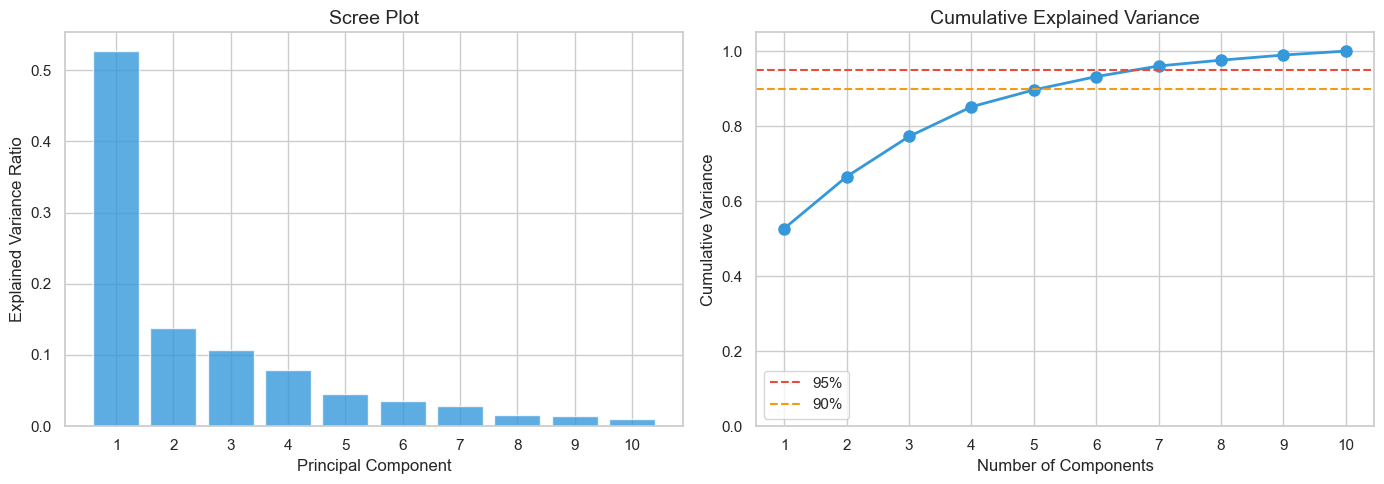

Explained variance per component:
  PC1: lambda=5.274, var=52.7%, cum=52.7%
  PC2: lambda=1.384, var=13.8%, cum=66.5%
  PC3: lambda=1.072, var=10.7%, cum=77.2%
  PC4: lambda=0.793, var=7.9%, cum=85.2%
  PC5: lambda=0.450, var=4.5%, cum=89.7%
  PC6: lambda=0.355, var=3.5%, cum=93.2%
  PC7: lambda=0.283, var=2.8%, cum=96.0%
  PC8: lambda=0.155, var=1.5%, cum=97.6%
  PC9: lambda=0.137, var=1.4%, cum=98.9%
  PC10: lambda=0.105, var=1.1%, cum=100.0%

Components for 95% variance: 7/10


In [13]:
# PCA from scratch
C = np.cov(X_train.T)
eigenvalues, eigenvectors = np.linalg.eigh(C)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(eigenvalues)+1), explained, color=COLORS[0], alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(eigenvalues)+1))

axes[1].plot(range(1, len(eigenvalues)+1), cumulative, 'o-', color=COLORS[0], lw=2, ms=8)
axes[1].axhline(0.95, color=COLORS[1], ls='--', label='95%')
axes[1].axhline(0.90, color=COLORS[3], ls='--', label='90%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xticks(range(1, len(eigenvalues)+1))
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n95 = int(np.argmax(cumulative >= 0.95) + 1)
print("Explained variance per component:")
for i, (ev, r) in enumerate(zip(eigenvalues, explained)):
    print(f"  PC{i+1}: lambda={ev:.3f}, var={r:.1%}, cum={cumulative[i]:.1%}")
print(f"\nComponents for 95% variance: {n95}/{len(eigenvalues)}")

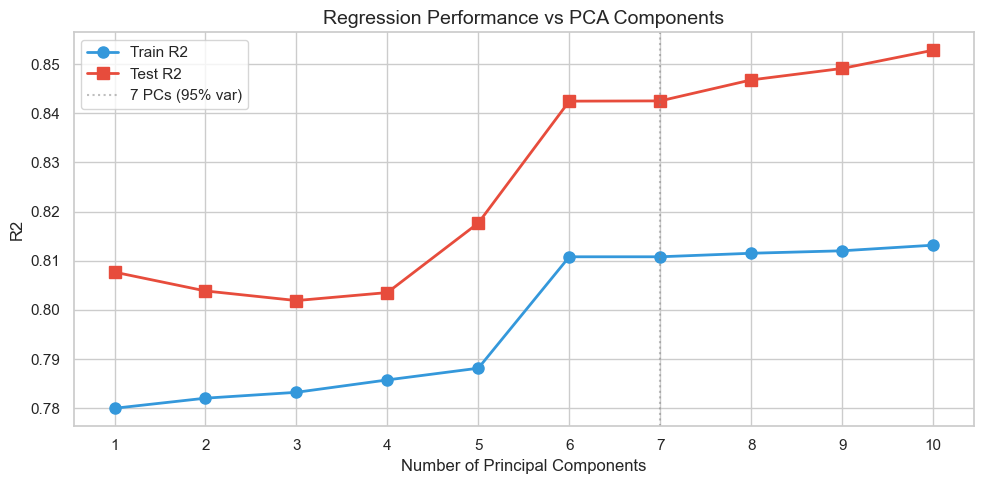

Full model (10 features): Test R2 = 0.8528
PCA model (7 components):  Test R2 = 0.8425


In [14]:
# Regression performance vs number of PCA components
pca_r2 = {}
for k in range(1, len(eigenvalues)+1):
    V = eigenvectors[:, :k]
    Z_tr, Z_te = X_train @ V, X_test @ V
    m = OLSRegression().fit(Z_tr, y_train)
    pca_r2[k] = evaluate(m, Z_tr, y_train, Z_te, y_test)

ks = list(pca_r2.keys())
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, [pca_r2[k]['r2_tr'] for k in ks], 'o-', color=COLORS[0], lw=2, ms=8, label='Train R2')
ax.plot(ks, [pca_r2[k]['r2_te'] for k in ks], 's-', color=COLORS[1], lw=2, ms=8, label='Test R2')
ax.axvline(n95, color='gray', ls=':', alpha=0.5, label=f'{n95} PCs (95% var)')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('R2')
ax.set_title('Regression Performance vs PCA Components')
ax.set_xticks(ks)
ax.legend()

plt.tight_layout()
plt.savefig('fig_pca_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Full model ({len(eigenvalues)} features): Test R2 = {pca_r2[len(eigenvalues)]['r2_te']:.4f}")
print(f"PCA model ({n95} components):  Test R2 = {pca_r2[n95]['r2_te']:.4f}")

### 8.2 Ridge Regularization (Session 5)

Ridge regression adds an $L_2$ penalty to prevent overfitting:

$$J_{\text{Ridge}} = \frac{1}{2n}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2 + \frac{\lambda}{2n}\|\boldsymbol{\theta}\|^2$$

Gradient: $\nabla J_{\text{Ridge}} = \frac{1}{n}\mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) + \frac{\lambda}{n}\boldsymbol{\theta}$

The penalty shrinks weights toward zero. Larger $\lambda$ = more regularization.

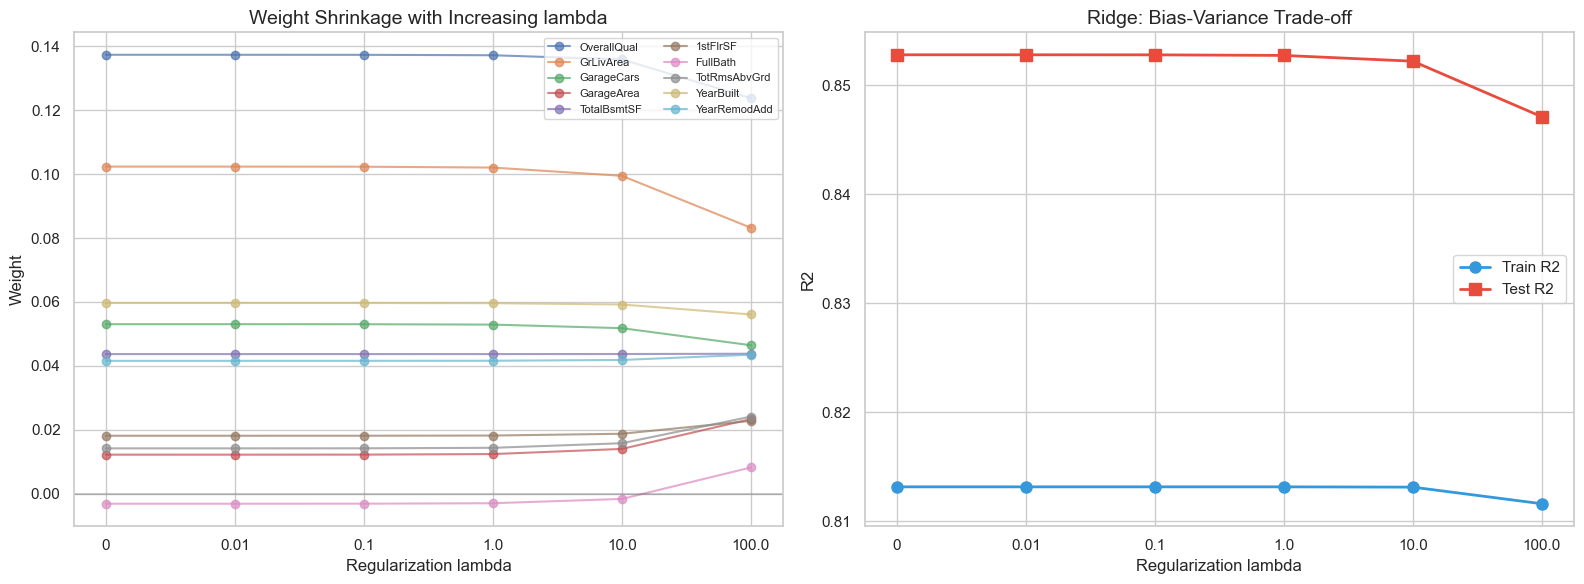

  lambda   Train R2    Test R2  ||theta||
------------------------------------------
    0.00     0.8132     0.8528     0.2001
    0.01     0.8132     0.8528     0.2001
    0.10     0.8132     0.8528     0.2001
    1.00     0.8132     0.8528     0.1998
   10.00     0.8131     0.8522     0.1975
  100.00     0.8116     0.8471     0.1819


In [15]:
class RidgeGD:
    def __init__(self, lr=0.1, n_iter=1000, lam=1.0):
        self.lr = lr
        self.n_iter = n_iter
        self.lam = lam
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n, p = X.shape
        self.weights = np.zeros(p)
        self.bias = 0.0
        self.cost_history = []
        for _ in range(self.n_iter):
            r = X @ self.weights + self.bias - y
            dw = (1/n) * (X.T @ r) + (self.lam/n) * self.weights
            db = (1/n) * np.sum(r)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            cost = (1/(2*n))*np.sum(r**2) + (self.lam/(2*n))*np.sum(self.weights**2)
            self.cost_history.append(cost)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

lambdas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
all_weights = []
for lam in lambdas:
    m = RidgeGD(lr=0.1, n_iter=1000, lam=lam).fit(X_train, y_train)
    ridge_models[lam] = m
    all_weights.append(m.weights.copy())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

W = np.array(all_weights)
for j in range(W.shape[1]):
    axes[0].plot([str(l) for l in lambdas], W[:, j], 'o-', label=selected[j], alpha=0.7, lw=1.5)
axes[0].set_xlabel('Regularization lambda')
axes[0].set_ylabel('Weight')
axes[0].set_title('Weight Shrinkage with Increasing lambda')
axes[0].legend(fontsize=8, ncol=2)
axes[0].axhline(0, color='k', ls='-', alpha=0.2)

tr_r2 = [evaluate(ridge_models[l], X_train, y_train, X_test, y_test)['r2_tr'] for l in lambdas]
te_r2 = [evaluate(ridge_models[l], X_train, y_train, X_test, y_test)['r2_te'] for l in lambdas]
axes[1].plot([str(l) for l in lambdas], tr_r2, 'o-', color=COLORS[0], lw=2, ms=8, label='Train R2')
axes[1].plot([str(l) for l in lambdas], te_r2, 's-', color=COLORS[1], lw=2, ms=8, label='Test R2')
axes[1].set_xlabel('Regularization lambda')
axes[1].set_ylabel('R2')
axes[1].set_title('Ridge: Bias-Variance Trade-off')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_ridge.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'lambda':>8} {'Train R2':>10} {'Test R2':>10} {'||theta||':>10}")
print("-" * 42)
for lam in lambdas:
    m = ridge_models[lam]
    me = evaluate(m, X_train, y_train, X_test, y_test)
    print(f"{lam:>8.2f} {me['r2_tr']:>10.4f} {me['r2_te']:>10.4f} {np.sqrt(np.sum(m.weights**2)):>10.4f}")

## 9. Conclusion

### Key Findings

1. **GD converges to the OLS solution** — with appropriate learning rate and sufficient iterations, parameters match to high precision.

2. **Learning rate is critical**: too small ($\alpha = 0.001$) means slow convergence; too large ($\alpha \geq 0.5$) risks oscillation or divergence. The bound $\alpha < 2/\lambda_{\max}$ guides selection.

3. **Standardization enables convergence** — without it, the condition number of $\mathbf{X}^T\mathbf{X}/n$ is large, causing directional imbalance.

4. **PCA preserves performance with fewer dimensions** — top principal components retain >90% variance with minimal $R^2$ loss.

5. **Ridge regularization controls complexity** — $L_2$ penalty shrinks weights, trading bias for reduced variance.

### Course Integration

| Session | Concept | Application |
|:---|:---|:---|
| 1 — Linear Algebra | Eigenvalues, PCA | Feature covariance decomposition |
| 2 — Calculus | Gradients, optimization | GD implementation, cost minimization |
| 3 — Probability | Distributions, normality | SalePrice log-transform analysis |
| 4 — Statistics | Hypothesis testing | Feature significance testing |
| 5 — Advanced | Regularization | Ridge gradient descent |

---
*Mathematics for Machine Learning — Albert School x Mines Paris PSL*